In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import statsmodels.api as sm

df = pd.read_csv('~/Desktop/datasets_AISL/Boston.csv')

In [14]:
# Let's create a mapping of each column/variable to its actual name
column_mapping = {
    'CRIM': 'Per capita crime rate by town',
    'ZN': 'Proportion of residential land zoned for lots over 25,000 sq.ft.',
    'INDUS': 'Proportion of non-retail business acres per town',
    'CHAS': 'Charles River dummy variable (1 if tract bounds river; 0 otherwise)',
    'NOX': 'Nitric oxides concentration (parts per 10 million)',
    'RM': 'Average number of rooms per dwelling',
    'AGE': 'Proportion of owner-occupied units built prior to 1940',
    'DIS': 'Weighted distances to five Boston employment centres',
    'RAD': 'Index of accessibility to radial highways',
    'TAX': 'Full-value property-tax rate per $10,000',
    'PTRATIO': 'Pupil-teacher ratio by town',
    'LSTAT': 'Percentage of lower status of the population',
    'MEDV': 'Median value of owner-occupied homes in $1000s',
}

In [16]:
# Let's explore the dataset first 
df.drop(columns=['Unnamed: 0'], inplace=True) # Drop the first column which is just an index
df.describe()


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


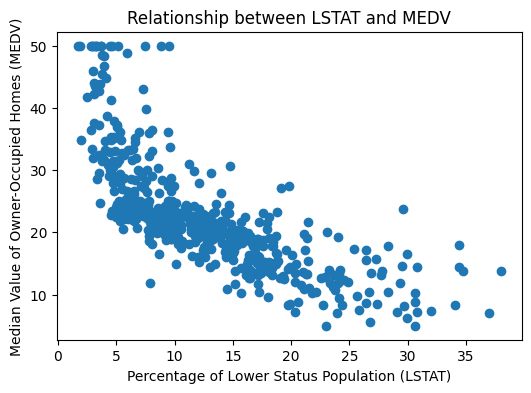

In [30]:
# First we are gonna make a simple linear regression model to predict 
# median value of owner-occupied homes (MEDV) based on percentage of lower status of the population (LSTAT)

# Let's explore the variables first
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.scatter(df['lstat'], df['medv'])
ax.set_xlabel('Percentage of Lower Status Population (LSTAT)')
ax.set_ylabel('Median Value of Owner-Occupied Homes (MEDV)')
ax.set_title('Relationship between LSTAT and MEDV')
plt.show()

In [31]:
# Let's now fit the model using statsmodels
# Add a constant for the intercept in the regression
X = sm.add_constant(df['lstat'])
y = df['medv']

In [32]:
model = sm.OLS(y, X)
results = model.fit()

In [33]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Mon, 25 May 2026   Prob (F-statistic):           5.08e-88
Time:                        18:29:57   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         34.5538      0.563     61.415      0.000      33.448      35.659
lstat         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [34]:
results.params


const    34.553841
lstat    -0.950049
dtype: float64

In [28]:
y.shape

(506,)